# Phase 1 Step 4 — 베이스라인 CNN 모델

**목표:** 커스텀 CNN으로 WM-811K 9-class 분류 베이스라인 구축

| 항목 | 내용 |
|------|------|
| 모델 | WaferCNN — 4 Conv Block + GAP + FC Head |
| 입력 | (B, 1, 64, 64) float32 |
| 출력 | (B, 9) logits |
| 손실 함수 | CrossEntropyLoss (class weight 적용) |
| 옵티마이저 | Adam (lr=1e-3, weight_decay=1e-4) |
| 스케줄러 | CosineAnnealingLR |
| **목표 성능** | **F1-Score macro ≥ 0.80** |

## 1. 환경 설정

In [1]:
import os
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.metrics import (
    f1_score, accuracy_score,
    confusion_matrix, classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A

warnings.filterwarnings('ignore')
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로
PROCESSED_DIR  = Path('data/processed')
CHECKPOINT_DIR = Path('checkpoints')
ANALYSIS_DIR   = Path('analysis')
CHECKPOINT_DIR.mkdir(exist_ok=True)
ANALYSIS_DIR.mkdir(exist_ok=True)

# ── 시드
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── 클래스 정의
CLASS_ORDER = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']
NUM_CLASSES = len(CLASS_ORDER)

# ── 학습 하이퍼파라미터
BATCH_SIZE   = 64
EPOCHS       = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.3
PATIENCE     = 7          # Early stopping patience
MODEL_NAME   = 'WaferCNN'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

PyTorch  : 2.6.0+cu124
Device   : cuda
GPU      : NVIDIA GeForce RTX 2060 SUPER
VRAM     : 8.0 GB


c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\.venv\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 2. 데이터 로드

`03_preprocessing.ipynb`에서 저장한 `all_maps_resized.npy`와 `split_indices.pkl`을 로드한다.

In [2]:
print('데이터 로드 중...')
all_maps_resized = np.load(PROCESSED_DIR / 'all_maps_resized.npy')
print(f'all_maps_resized : {all_maps_resized.shape}  dtype={all_maps_resized.dtype}  ({all_maps_resized.nbytes/1024**2:.0f} MB)')

with open(PROCESSED_DIR / 'split_indices.pkl', 'rb') as f:
    split = pickle.load(f)

train_idx      = split['train_idx']
val_idx        = split['val_idx']
test_idx       = split['test_idx']
encoded_labels = split['encoded_labels']
class_weights  = split['class_weights']

print(f'Train: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}')

# ── Dataset
class WaferMapDataset(Dataset):
    def __init__(self, maps_array, labels, transform=None, norm_divisor=2.0):
        self.maps_array   = maps_array
        self.labels       = labels
        self.transform    = transform
        self.norm_divisor = norm_divisor

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        wmap = self.maps_array[idx].astype(np.float32) / self.norm_divisor
        if self.transform is not None:
            wmap = self.transform(image=wmap[:, :, np.newaxis])['image'][:, :, 0]
        tensor = torch.from_numpy(np.clip(wmap, 0.0, 1.0).copy()).unsqueeze(0)
        label  = torch.tensor(self.labels[idx], dtype=torch.long)
        return tensor, label

train_transform = A.Compose([
    A.Rotate(limit=20, border_mode=0, value=0.0, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    A.Blur(blur_limit=3, p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.2),
    A.CoarseDropout(max_holes=4, max_height=8, max_width=8,
                    min_holes=1, min_height=4, min_width=4, fill_value=0.0, p=0.3),
])

train_labels_arr = encoded_labels[train_idx].astype(int)
val_labels_arr   = encoded_labels[val_idx].astype(int)
test_labels_arr  = encoded_labels[test_idx].astype(int)

train_dataset = WaferMapDataset(all_maps_resized[train_idx], train_labels_arr, transform=train_transform)
val_dataset   = WaferMapDataset(all_maps_resized[val_idx],   val_labels_arr)
test_dataset  = WaferMapDataset(all_maps_resized[test_idx],  test_labels_arr)

sample_weights   = class_weights[train_labels_arr]
weighted_sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(train_labels_arr),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=weighted_sampler, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imgs, lbls = next(iter(train_loader))
print(f'배치 shape: {imgs.shape}  dtype={imgs.dtype}  labels={lbls.shape}')

데이터 로드 중...
all_maps_resized : (172950, 64, 64)  dtype=uint8  (676 MB)
Train: 121,065  Val: 25,942  Test: 25,943
배치 shape: torch.Size([64, 1, 64, 64])  dtype=torch.float32  labels=torch.Size([64])


## 3. 커스텀 CNN 모델 설계

```
입력 (1, 64, 64)
  ↓ Block 1: Conv(1→32) × 2 + BN + ReLU + MaxPool2d → (32, 32, 32)
  ↓ Block 2: Conv(32→64) × 2 + BN + ReLU + MaxPool2d → (64, 16, 16)
  ↓ Block 3: Conv(64→128) × 2 + BN + ReLU + MaxPool2d → (128, 8, 8)
  ↓ Block 4: Conv(128→256) × 2 + BN + ReLU + MaxPool2d → (256, 4, 4)
  ↓ AdaptiveAvgPool2d(1) → Flatten → (256,)
  ↓ FC(256→128) + ReLU + Dropout
  ↓ FC(128→9) → logits
```

In [3]:
class WaferCNN(nn.Module):
    """커스텀 CNN 베이스라인 — 4 Conv Block + Global Avg Pool + FC Head.

    입력: (B, 1, 64, 64) float32
    출력: (B, 9) logits
    """

    def __init__(self, num_classes: int = 9, dropout: float = 0.3):
        super().__init__()

        def _block(in_ch, out_ch, drop=0.1):
            return nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(drop),
            )

        self.block1 = _block(1,   32,  drop=0.10)  # 64→32
        self.block2 = _block(32,  64,  drop=0.10)  # 32→16
        self.block3 = _block(64,  128, drop=0.15)  # 16→8
        self.block4 = _block(128, 256, drop=0.20)  #  8→4

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.head(x)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## 4. 모델 검증 — 파라미터 수 & Forward 테스트

In [4]:
model = WaferCNN(num_classes=NUM_CLASSES, dropout=DROPOUT).to(DEVICE)

# ── 파라미터 수
total_params = model.count_params()
print(f'총 학습 가능 파라미터: {total_params:,}개  ({total_params/1e6:.2f}M)')

# ── 레이어별 출력 크기 확인
x = torch.zeros(2, 1, 64, 64).to(DEVICE)
print('\n레이어별 출력 shape:')
print(f'  입력      : {tuple(x.shape)}')
x = model.block1(x); print(f'  block1    : {tuple(x.shape)}')
x = model.block2(x); print(f'  block2    : {tuple(x.shape)}')
x = model.block3(x); print(f'  block3    : {tuple(x.shape)}')
x = model.block4(x); print(f'  block4    : {tuple(x.shape)}')

# ── 전체 forward 검증
model = WaferCNN(num_classes=NUM_CLASSES, dropout=DROPOUT).to(DEVICE)
dummy = torch.zeros(2, 1, 64, 64).to(DEVICE)
out = model(dummy)
print(f'  출력 logit: {tuple(out.shape)}  ✓')

총 학습 가능 파라미터: 1,206,697개  (1.21M)

레이어별 출력 shape:
  입력      : (2, 1, 64, 64)
  block1    : (2, 32, 32, 32)
  block2    : (2, 64, 16, 16)
  block3    : (2, 128, 8, 8)
  block4    : (2, 256, 4, 4)
  출력 logit: (2, 9)  ✓


## 5. 학습 설정

- **Loss:** CrossEntropyLoss + class weight (클래스 불균형 보정)
- **Optimizer:** Adam (lr=1e-3, weight_decay=1e-4)
- **Scheduler:** CosineAnnealingLR (T_max=EPOCHS)
- **Early Stopping:** val F1-macro 기준, patience=7

In [5]:
class_weight_tensor = torch.FloatTensor(class_weights).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Loss     : CrossEntropyLoss (class weight 적용)')
print(f'Optimizer: Adam  lr={LR}  weight_decay={WEIGHT_DECAY}')
print(f'Scheduler: CosineAnnealingLR  T_max={EPOCHS}')
print(f'Device   : {DEVICE}')

Loss     : CrossEntropyLoss (class weight 적용)
Optimizer: Adam  lr=0.001  weight_decay=0.0001
Scheduler: CosineAnnealingLR  T_max=30
Device   : cuda


## 6. 학습 루프 함수

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        preds    = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return running_loss / total, correct / total, f1, all_preds, all_labels


print('train_one_epoch / eval_epoch 정의 완료')

train_one_epoch / eval_epoch 정의 완료


## 7. 학습 실행

- 매 에포크마다 val F1-macro 기록
- best val F1 갱신 시 체크포인트 저장
- `patience=7` 에포크 동안 개선 없으면 Early Stopping

In [7]:
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1': [],
    'lr': []
}

best_val_f1   = 0.0
best_ckpt_path = None
patience_cnt  = 0

print(f'{'Epoch':>5} | {'LR':>8} | {'Tr Loss':>8} | {'Tr Acc':>7} | {'Vl Loss':>8} | {'Vl Acc':>7} | {'Vl F1':>7} | {'Best':>5}')
print('-' * 80)

for epoch in range(1, EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, vl_f1, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['val_f1'].append(vl_f1)
    history['lr'].append(current_lr)

    is_best = vl_f1 > best_val_f1
    if is_best:
        best_val_f1 = vl_f1
        patience_cnt = 0
        ckpt_name = f'{MODEL_NAME}_{epoch:02d}_{vl_f1:.4f}.pth'
        ckpt_path = CHECKPOINT_DIR / ckpt_name
        torch.save({
            'epoch':       epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_f1':      vl_f1,
            'val_acc':     vl_acc,
            'config':      {'num_classes': NUM_CLASSES, 'dropout': DROPOUT},
        }, ckpt_path)
        best_ckpt_path = ckpt_path
    else:
        patience_cnt += 1

    best_mark = '★' if is_best else ''
    print(f'{epoch:>5} | {current_lr:>8.2e} | {tr_loss:>8.4f} | {tr_acc:>7.4f} | '
          f'{vl_loss:>8.4f} | {vl_acc:>7.4f} | {vl_f1:>7.4f} | {best_mark:>5}')

    if patience_cnt >= PATIENCE:
        print(f'\nEarly Stopping at epoch {epoch} (patience={PATIENCE})')
        break

print(f'\n학습 완료 — Best Val F1: {best_val_f1:.4f}')
print(f'최적 체크포인트: {best_ckpt_path}')

Epoch |       LR |  Tr Loss |  Tr Acc |  Vl Loss |  Vl Acc |   Vl F1 |  Best
--------------------------------------------------------------------------------
    1 | 1.00e-03 |   0.3355 |  0.5339 |   1.2684 |  0.1067 |  0.5024 |     ★
    2 | 9.97e-04 |   0.1910 |  0.7018 |   1.2000 |  0.1161 |  0.3998 |      
    3 | 9.89e-04 |   0.1486 |  0.7449 |   0.9311 |  0.1261 |  0.4408 |      
    4 | 9.76e-04 |   0.1234 |  0.7631 |   0.8477 |  0.1286 |  0.4614 |      
    5 | 9.57e-04 |   0.1102 |  0.7740 |   0.6836 |  0.1286 |  0.4616 |      
    6 | 9.33e-04 |   0.1004 |  0.7824 |   0.7250 |  0.1287 |  0.4589 |      
    7 | 9.05e-04 |   0.0886 |  0.7895 |   0.6743 |  0.1328 |  0.4940 |      
    8 | 8.72e-04 |   0.0851 |  0.7940 |   0.6751 |  0.1297 |  0.4439 |      

Early Stopping at epoch 8 (patience=7)

학습 완료 — Best Val F1: 0.5024
최적 체크포인트: checkpoints\WaferCNN_01_0.5024.pth


## 8. 학습 곡선 시각화

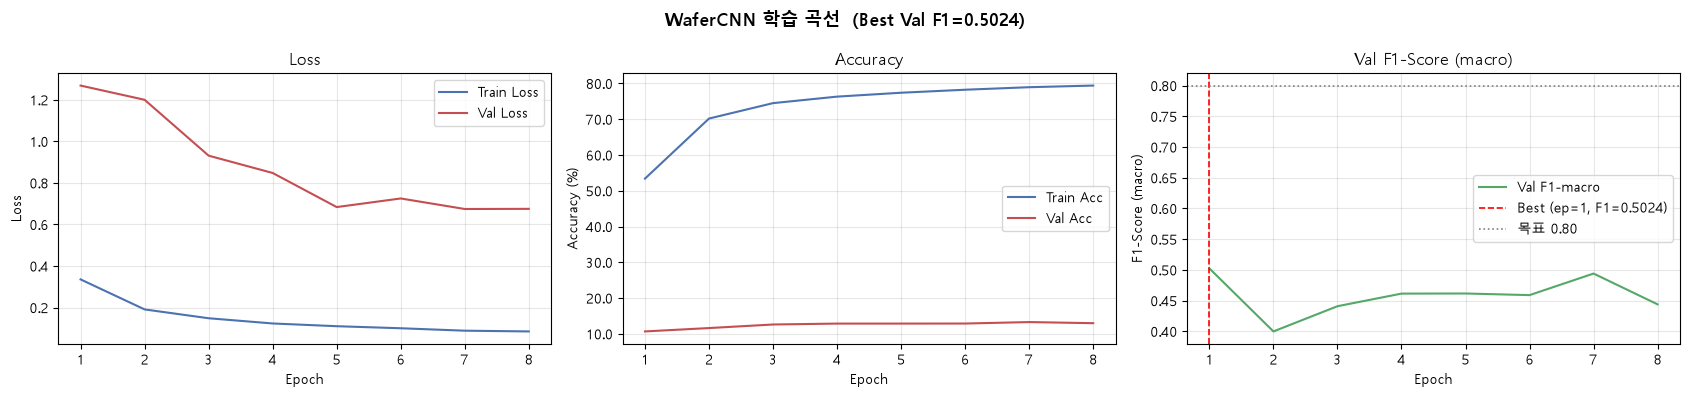

저장 완료: analysis\baseline_training_curves.png


In [8]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle(f'{MODEL_NAME} 학습 곡선  (Best Val F1={best_val_f1:.4f})',
             fontsize=13, fontweight='bold')

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='#4C72B0')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='#C44E52')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, [v*100 for v in history['train_acc']], label='Train Acc', color='#4C72B0')
axes[1].plot(epochs_ran, [v*100 for v in history['val_acc']],   label='Val Acc',   color='#C44E52')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# F1-macro
best_ep = int(np.argmax(history['val_f1'])) + 1
axes[2].plot(epochs_ran, history['val_f1'], label='Val F1-macro', color='#55A868')
axes[2].axvline(best_ep, color='red', linestyle='--', linewidth=1.2,
                label=f'Best (ep={best_ep}, F1={best_val_f1:.4f})')
axes[2].axhline(0.80, color='gray', linestyle=':', linewidth=1.2, label='목표 0.80')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1-Score (macro)')
axes[2].set_title('Val F1-Score (macro)'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
save_path = ANALYSIS_DIR / 'baseline_training_curves.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {save_path}')

## 9. 최종 평가 (Test Set)

Best 체크포인트를 로드하여 Test Set으로 최종 성능 측정

체크포인트 로드: epoch=1  val_f1=0.5024

=== Test 성능 ===
Accuracy       : 10.65%
F1-Score macro : 0.5014  (목표 ≥ 0.80)
목표 달성 여부 : ❌ 미달

=== 클래스별 Classification Report ===
              precision    recall  f1-score   support

        none       0.00      0.00      0.00     22115
      Center       0.62      0.88      0.73       644
       Donut       0.45      0.94      0.60        83
    Edge-Loc       0.36      0.46      0.40       779
   Edge-Ring       0.82      0.89      0.86      1452
         Loc       0.79      0.28      0.41       539
   Near-full       0.73      1.00      0.85        22
      Random       0.49      0.93      0.65       130
     Scratch       0.01      0.96      0.02       179

    accuracy                           0.11     25943
   macro avg       0.48      0.70      0.50     25943
weighted avg       0.09      0.11      0.09     25943



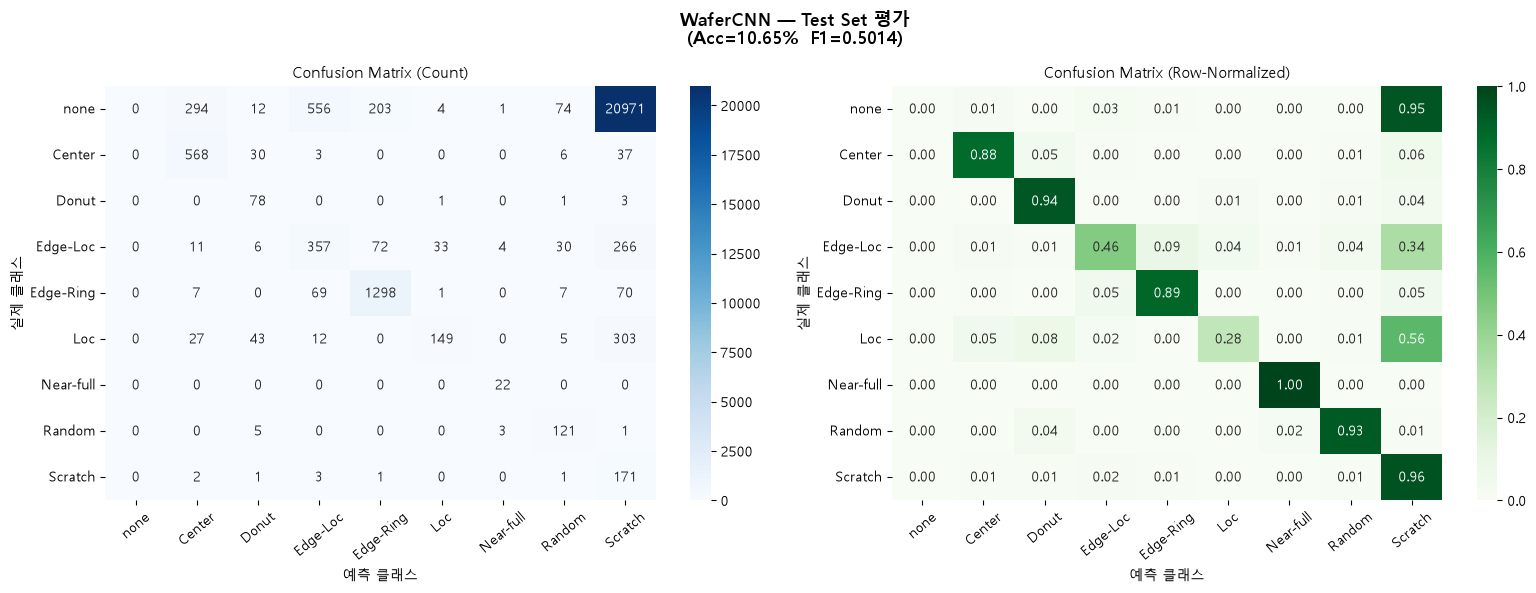

저장 완료: analysis\baseline_confusion_matrix.png


In [9]:
# ── Best 체크포인트 로드
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'체크포인트 로드: epoch={ckpt["epoch"]}  val_f1={ckpt["val_f1"]:.4f}')

# ── Test 평가
_, test_acc, test_f1, test_preds, test_labels = eval_epoch(model, test_loader, criterion, DEVICE)
print(f'\n=== Test 성능 ===')
print(f'Accuracy       : {test_acc*100:.2f}%')
print(f'F1-Score macro : {test_f1:.4f}  (목표 ≥ 0.80)')
target_met = '✅ 달성' if test_f1 >= 0.80 else '❌ 미달'
print(f'목표 달성 여부 : {target_met}')

# ── 클래스별 성능
print(f'\n=== 클래스별 Classification Report ===')
print(classification_report(test_labels, test_preds,
                             target_names=CLASS_ORDER, zero_division=0))

# ── Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{MODEL_NAME} — Test Set 평가\n(Acc={test_acc*100:.2f}%  F1={test_f1:.4f})',
             fontsize=13, fontweight='bold')

# 원본 confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)', fontsize=11)
axes[0].set_xlabel('예측 클래스', fontsize=10)
axes[0].set_ylabel('실제 클래스', fontsize=10)
axes[0].tick_params(axis='x', rotation=40)

# 정규화 confusion matrix
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix (Row-Normalized)', fontsize=11)
axes[1].set_xlabel('예측 클래스', fontsize=10)
axes[1].set_ylabel('실제 클래스', fontsize=10)
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
save_path = ANALYSIS_DIR / 'baseline_confusion_matrix.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장 완료: {save_path}')

## 10. 산출물 저장 및 `src/model.py` 생성

In [10]:
import json

# ── 성능 기록 저장
results = {
    'model': MODEL_NAME,
    'best_epoch':    ckpt['epoch'],
    'best_val_f1':   round(float(best_val_f1), 4),
    'test_accuracy': round(float(test_acc), 4),
    'test_f1_macro': round(float(test_f1), 4),
    'target_met':    bool(test_f1 >= 0.80),
    'hyperparams': {
        'epochs':       EPOCHS,
        'batch_size':   BATCH_SIZE,
        'lr':           LR,
        'weight_decay': WEIGHT_DECAY,
        'dropout':      DROPOUT,
        'optimizer':    'Adam',
        'scheduler':    'CosineAnnealingLR',
    },
    'best_checkpoint': str(best_ckpt_path),
}

results_path = ANALYSIS_DIR / 'baseline_results.json'
with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f'성능 기록 저장: {results_path}')

# ── src/model.py 생성
MODEL_CODE = '''
"""WM-811K 웨이퍼 불량 분류 모델 모음 (Phase 1)"""

import torch
import torch.nn as nn

NUM_CLASSES = 9


class WaferCNN(nn.Module):
    """커스텀 CNN 베이스라인 — 4 Conv Block + Global Avg Pool + FC Head.

    입력: (B, 1, 64, 64) float32
    출력: (B, num_classes) logits
    """

    def __init__(self, num_classes: int = NUM_CLASSES, dropout: float = 0.3):
        super().__init__()

        def _block(in_ch, out_ch, drop=0.1):
            return nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Dropout2d(drop),
            )

        self.block1 = _block(1,   32,  drop=0.10)
        self.block2 = _block(32,  64,  drop=0.10)
        self.block3 = _block(64,  128, drop=0.15)
        self.block4 = _block(128, 256, drop=0.20)

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.head(x)

    def count_params(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def load_wafer_cnn(checkpoint_path: str, device=None) -> WaferCNN:
    """체크포인트에서 WaferCNN 로드."""
    if device is None:
        device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg  = ckpt.get(\'config\', {\'num_classes\': NUM_CLASSES, \'dropout\': 0.3})
    model = WaferCNN(**cfg).to(device)
    model.load_state_dict(ckpt[\'model_state\'])
    model.eval()
    return model
'''.strip()

src_path = Path('src/model.py')
src_path.parent.mkdir(exist_ok=True)
with open(src_path, 'w', encoding='utf-8') as f:
    f.write(MODEL_CODE + '\n')
print(f'src/model.py 생성 완료: {src_path.resolve()}')

print()
print('=== Phase 1 Step 4 완료 ===')
print(f'  Best Val F1 : {best_val_f1:.4f}')
print(f'  Test F1     : {test_f1:.4f}  ({target_met})')
print(f'  체크포인트  : {best_ckpt_path}')
print()
print('다음 단계: 05_finetuning.ipynb  (MobileNetV3 + timm)')

성능 기록 저장: analysis\baseline_results.json
src/model.py 생성 완료: C:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\src\model.py

=== Phase 1 Step 4 완료 ===
  Best Val F1 : 0.5024
  Test F1     : 0.5014  (❌ 미달)
  체크포인트  : checkpoints\WaferCNN_01_0.5024.pth

다음 단계: 05_finetuning.ipynb  (MobileNetV3 + timm)
